# Amazon.in Apparel Seller: Operations Review (Apr–Jun 2022)

Charts and statistical checks behind the README. Reads the clean data from `python/01_clean.py`; run `./run_all.sh` first.

**Net revenue** means shipped orders only. Cancelled, returned and pending orders are excluded.

In [1]:
from math import erfc, sqrt
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

CHARTS = Path("../outputs/charts")
CHARTS.mkdir(parents=True, exist_ok=True)

# One default colour; saffron = "focus here"; red = "problem"; grey = context.
TEAL, SAFFRON, VIOLET, RED, GREY = "#0f9488", "#d9731c", "#6d4bc4", "#c23b3b", "#b3b7be"
INK, INK_2, MUTED = "#111827", "#4b5563", "#8a909b"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.family": "sans-serif", "font.size": 10,
    "axes.edgecolor": "#c9cdd3", "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "figure.facecolor": "white", "axes.facecolor": "white",
})

def inr(x, pos=None):
    return f"₹{x/1e6:,.1f}M" if abs(x) >= 1e6 else f"₹{x/1e3:,.0f}K"

def bare(ax, axis="x"):
    (ax.set_xticks if axis == "x" else ax.set_yticks)([])
    ax.spines["bottom" if axis == "x" else "left"].set_visible(False)

def footnote(ax, text, y=-0.14):
    ax.text(0, y, text, transform=ax.transAxes, color=MUTED, fontsize=8)

o = pd.read_csv("../data/clean/orders_clean.csv", low_memory=False, parse_dates=["order_date"])
stock = pd.read_csv("../data/clean/stock_clean.csv")
shipped = o[o.outcome == "Shipped"]
print(f"{len(o):,} order lines | net revenue ₹{o.net_revenue_inr.sum()/1e6:.1f}M | cancelled {(o.outcome == 'Cancelled').mean():.1%}")

128,969 order lines | net revenue ₹69.7M | cancelled 14.2%


## 1. What the 2024 version got wrong

The 2024 cleaning deleted every row with no amount. Most of those rows are cancelled orders, so the cancellation rate looked far lower than it is.

,2024 version,This version
Order lines,"121,180.000","128,969.000"
Cancellation rate,0.089,0.142
Revenue reported (₹),"78,592,678.300","69,660,658.000"


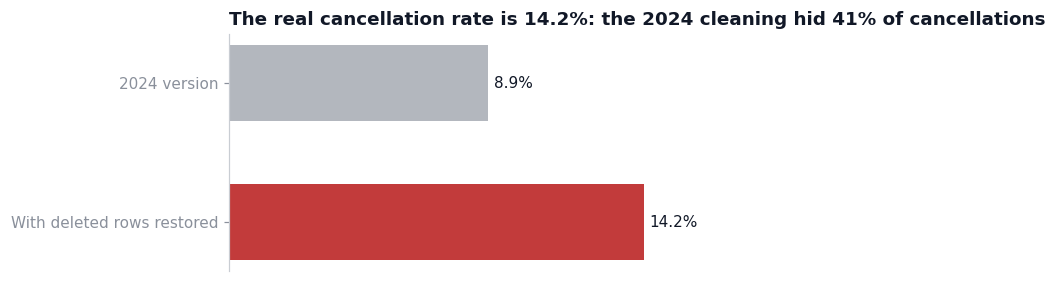

In [2]:
old = pd.read_csv("../archive_2024/2024_cleaned_data.csv.gz", usecols=["Status", "Amount"])
compare = pd.DataFrame({
    "2024 version": [len(old), (old.Status == "Cancelled").mean(), old.Amount.sum()],
    "This version": [len(o), (o.outcome == "Cancelled").mean(), o.net_revenue_inr.sum()],
}, index=["Order lines", "Cancellation rate", "Revenue reported (₹)"])
display(compare.style.format({"2024 version": "{:,.3f}", "This version": "{:,.3f}"}))

fig, ax = plt.subplots(figsize=(6.5, 2.8))
vals = [compare.loc["Cancellation rate", "2024 version"], compare.loc["Cancellation rate", "This version"]]
bars = ax.barh(["2024 version", "With deleted rows restored"], vals, color=[GREY, RED], height=0.55)
ax.bar_label(bars, [f"{v:.1%}" for v in vals], padding=4, color=INK)
ax.invert_yaxis(); ax.set_xlim(0, 0.19); bare(ax)
hidden = 1 - (old.Status == "Cancelled").sum() / (o.outcome == "Cancelled").sum()
ax.set_title(f"The real cancellation rate is 14.2%: the 2024 cleaning hid {hidden:.0%} of cancellations")
fig.savefig(CHARTS / "01_cancellation_2024_vs_now.png")
plt.show()

## 2. Where ordered value ends up

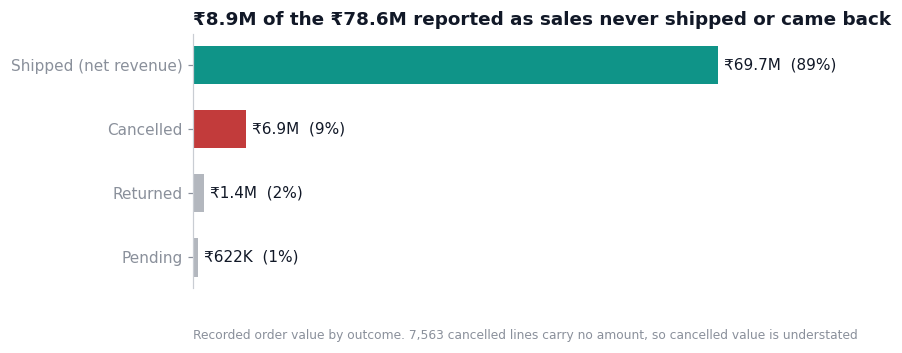

In [3]:
flow = o.groupby("outcome").amount_inr.sum().reindex(["Shipped", "Cancelled", "Returned", "Pending"])
labels = ["Shipped (net revenue)", "Cancelled", "Returned", "Pending"]
fig, ax = plt.subplots(figsize=(8, 3.0))
bars = ax.barh(labels, flow.values, color=[TEAL, RED, GREY, GREY], height=0.6)
ax.bar_label(bars, [f"{inr(v)}  ({v/flow.sum():.0%})" for v in flow.values], padding=4, color=INK)
ax.invert_yaxis(); ax.set_xlim(0, flow.max() * 1.3); bare(ax)
gross = o.amount_inr.sum()
ax.set_title(f"₹{(gross - flow['Shipped'])/1e6:.1f}M of the ₹{gross/1e6:.1f}M reported as sales never shipped or came back")
footnote(ax, "Recorded order value by outcome. 7,563 cancelled lines carry no amount, so cancelled value is understated", y=-0.2)
fig.savefig(CHARTS / "02_order_value_by_outcome.png")
plt.show()

## 3. Ship it yourself, or let Amazon do it?

Is the difference in cancellation rate real, or could it be chance? A two-proportion z-test.

Amazon 12.8% (n=89,692) | Seller 17.5% (n=39,277)
Gap +4.7% points, 95% CI [+4.2%, +5.1%], z = 22.2, p < 0.001


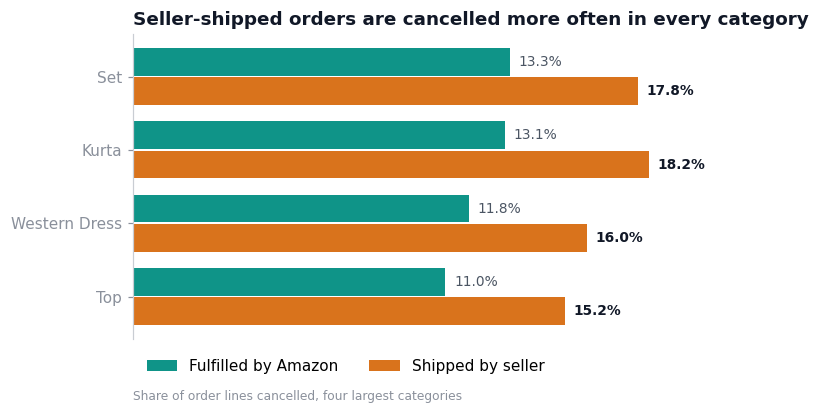

In [4]:
g = o.assign(cancelled=o.outcome.eq("Cancelled")).groupby("fulfilment").cancelled.agg(["sum", "count", "mean"])
a, s = g.loc["Fulfilled by Amazon"], g.loc["Shipped by seller"]
p_pool = (a["sum"] + s["sum"]) / (a["count"] + s["count"])
se = sqrt(p_pool * (1 - p_pool) * (1 / a["count"] + 1 / s["count"]))
z = (s["mean"] - a["mean"]) / se
p_value = erfc(abs(z) / sqrt(2))
diff_se = sqrt(a["mean"] * (1 - a["mean"]) / a["count"] + s["mean"] * (1 - s["mean"]) / s["count"])
print(f"Amazon {a['mean']:.1%} (n={int(a['count']):,}) | Seller {s['mean']:.1%} (n={int(s['count']):,})")
print(f"Gap {s['mean'] - a['mean']:+.1%} points, 95% CI [{s['mean'] - a['mean'] - 1.96*diff_se:+.1%}, {s['mean'] - a['mean'] + 1.96*diff_se:+.1%}], z = {z:.1f}, p {'< 0.001' if p_value < 0.001 else f'= {p_value:.3f}'}")

by_cat = (o.assign(cancelled=o.outcome.eq("Cancelled"))
            .pivot_table(index="category", columns="fulfilment", values="cancelled", aggfunc="mean")
            .loc[["Set", "Kurta", "Western Dress", "Top"]])
fig, ax = plt.subplots(figsize=(8, 3.6))
y = np.arange(len(by_cat))
ax.barh(y - 0.2, by_cat["Fulfilled by Amazon"], height=0.38, color=TEAL, label="Fulfilled by Amazon")
ax.barh(y + 0.2, by_cat["Shipped by seller"], height=0.38, color=SAFFRON, label="Shipped by seller")
for i, (am, se_) in enumerate(zip(by_cat["Fulfilled by Amazon"], by_cat["Shipped by seller"])):
    ax.text(am + 0.003, i - 0.2, f"{am:.1%}", va="center", color=INK_2, fontsize=9)
    ax.text(se_ + 0.003, i + 0.2, f"{se_:.1%}", va="center", color=INK, fontsize=9, fontweight="bold")
ax.set_yticks(y, by_cat.index); ax.invert_yaxis(); ax.set_xlim(0, 0.24); bare(ax)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0, -0.02), ncol=2)
ax.set_title("Seller-shipped orders are cancelled more often in every category")
footnote(ax, "Share of order lines cancelled, four largest categories", y=-0.2)
fig.savefig(CHARTS / "03_cancellation_by_fulfilment.png")
plt.show()

## 4. Revenue is falling, and one category explains most of it

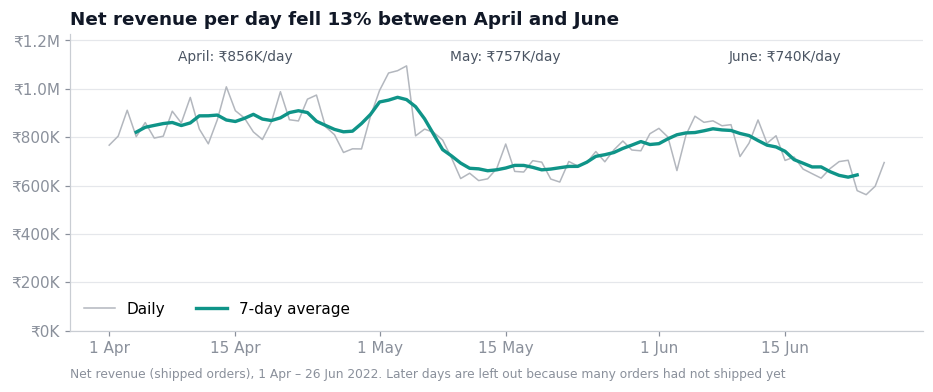

In [5]:
trend = o[o.in_trend == 1]
daily = trend.groupby("order_date").net_revenue_inr.sum()
roll = daily.rolling(7, center=True).mean()
monthly = trend.groupby("month").agg(rev=("net_revenue_inr", "sum"), days=("order_date", "nunique"))
monthly["per_day"] = monthly.rev / monthly.days

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(daily.index, daily.values, color=GREY, linewidth=1, label="Daily")
ax.plot(roll.index, roll.values, color=TEAL, linewidth=2.2, label="7-day average")
for m, row in monthly.iterrows():
    mid = pd.Timestamp(m + "-15")
    ax.text(mid, daily.max() * 1.02, f"{pd.Timestamp(m + '-01'):%B}: {inr(row.per_day)}/day", ha="center", color=INK_2, fontsize=9)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(inr)); ax.set_ylim(0, daily.max() * 1.12)
ax.grid(axis="y", color="#e5e7eb", linewidth=0.8); ax.legend(frameon=False, loc="lower left", ncol=2)
drop = monthly.per_day.iloc[-1] / monthly.per_day.iloc[0] - 1
ax.set_title(f"Net revenue per day fell {abs(drop):.0%} between April and June")
ax.xaxis.set_major_formatter(__import__("matplotlib.dates").dates.DateFormatter("%-d %b"))
footnote(ax, "Net revenue (shipped orders), 1 Apr – 26 Jun 2022. Later days are left out because many orders had not shipped yet", y=-0.16)
fig.savefig(CHARTS / "04_revenue_trend.png")
plt.show()

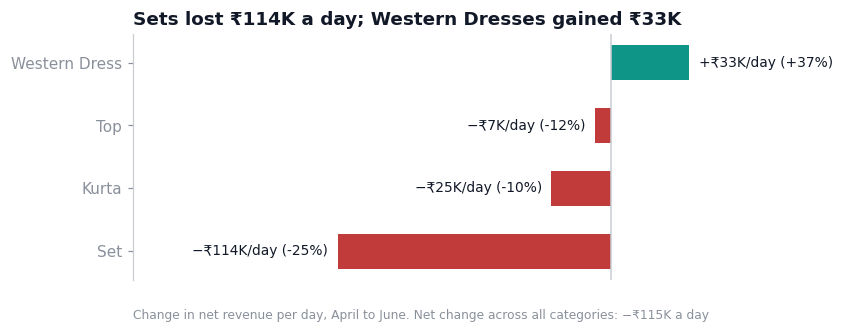

In [6]:
cat = (trend.pivot_table(index="category", columns="month", values="net_revenue_inr", aggfunc="sum")
            .div(monthly.days, axis=1))
cat["change"] = cat["2022-06"] - cat["2022-04"]
cat = cat.loc[["Set", "Kurta", "Top", "Western Dress"]].sort_values("change")

fig, ax = plt.subplots(figsize=(8, 2.9))
bars = ax.barh(cat.index, cat.change, color=[RED if v < 0 else TEAL for v in cat.change], height=0.55)
for b, v, a0, j0 in zip(bars, cat.change, cat["2022-04"], cat["2022-06"]):
    ax.text(v + (4000 if v > 0 else -4000), b.get_y() + b.get_height() / 2,
            f"{'+' if v > 0 else '−'}{inr(abs(v))}/day ({j0/a0 - 1:+.0%})", va="center", ha="left" if v > 0 else "right", color=INK, fontsize=9)
ax.axvline(0, color="#c9cdd3", linewidth=1); ax.set_xlim(cat.change.min() * 1.75, cat.change.max() * 2.6); bare(ax)
total = monthly.per_day.iloc[-1] - monthly.per_day.iloc[0]
ax.set_title(f"Sets lost {inr(abs(cat.loc['Set', 'change']))} a day; Western Dresses gained {inr(cat.loc['Western Dress', 'change'])}")
footnote(ax, f"Change in net revenue per day, April to June. Net change across all categories: −{inr(abs(total))} a day", y=-0.16)
fig.savefig(CHARTS / "05_category_change.png")
plt.show()

## 5. A small share of products carries the business

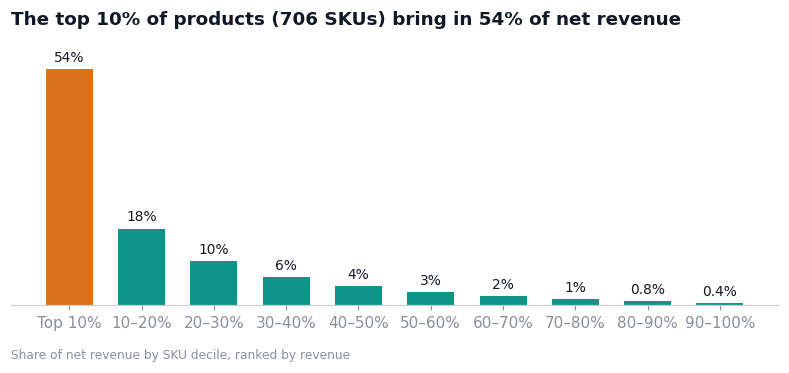

In [7]:
sku = shipped.groupby("sku").net_revenue_inr.sum().sort_values(ascending=False)
sku = sku[sku > 0]
decile = pd.qcut(np.arange(len(sku)), 10, labels=["Top 10%"] + [f"{i*10}–{i*10+10}%" for i in range(1, 10)])
share = sku.groupby(decile, observed=True).sum() / sku.sum()

fig, ax = plt.subplots(figsize=(9, 3.2))
bars = ax.bar(share.index.astype(str), share.values, color=[SAFFRON] + [TEAL] * 9, width=0.65)
ax.bar_label(bars, [f"{v:.0%}" if v >= 0.01 else f"{v:.1%}" for v in share.values], padding=3, color=INK, fontsize=9)
bare(ax, "y"); ax.set_ylim(0, share.max() * 1.15)
ax.set_title(f"The top 10% of products ({len(sku)//10} SKUs) bring in {share.iloc[0]:.0%} of net revenue")
footnote(ax, "Share of net revenue by SKU decile, ranked by revenue", y=-0.2)
fig.savefig(CHARTS / "06_sku_concentration.png")
plt.show()

## 6. Stock: thin where it sells, deep where it doesn't

Weeks of cover = stock on hand ÷ average units shipped per week (13 weeks). The stock snapshot is undated, so these are indicative.

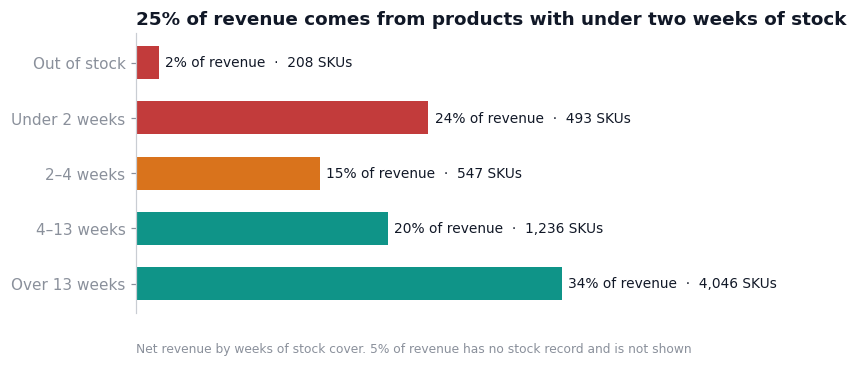

In [8]:
d = shipped.groupby("sku").agg(units=("qty", "sum"), rev=("net_revenue_inr", "sum")).reset_index()
d = d[d.units > 0].merge(stock[["sku", "stock_units"]], on="sku", how="left")
d["cover"] = d.stock_units / (d.units / 13)
bands = ["Out of stock", "Under 2 weeks", "2–4 weeks", "4–13 weeks", "Over 13 weeks"]
d["band"] = np.select([d.stock_units.isna(), d.stock_units == 0, d.cover < 2, d.cover < 4, d.cover < 13],
                      ["No stock record", bands[0], bands[1], bands[2], bands[3]], default=bands[4])
by_band = d.groupby("band").agg(skus=("sku", "size"), rev=("rev", "sum")).reindex(bands)
rev_share = by_band.rev / d.rev.sum()

fig, ax = plt.subplots(figsize=(8, 3.3))
bars = ax.barh(by_band.index, rev_share.values, color=[RED, RED, SAFFRON, TEAL, TEAL], height=0.6)
ax.bar_label(bars, [f"{v:.0%} of revenue  ·  {int(n):,} SKUs" for v, n in zip(rev_share.values, by_band.skus)], padding=4, color=INK, fontsize=9)
ax.invert_yaxis(); ax.set_xlim(0, rev_share.max() * 1.6); bare(ax)
thin = rev_share.loc[["Out of stock", "Under 2 weeks"]].sum()
ax.set_title(f"{thin:.0%} of revenue comes from products with under two weeks of stock")
footnote(ax, "Net revenue by weeks of stock cover. 5% of revenue has no stock record and is not shown", y=-0.14)
fig.savefig(CHARTS / "07_stock_cover.png")
plt.show()

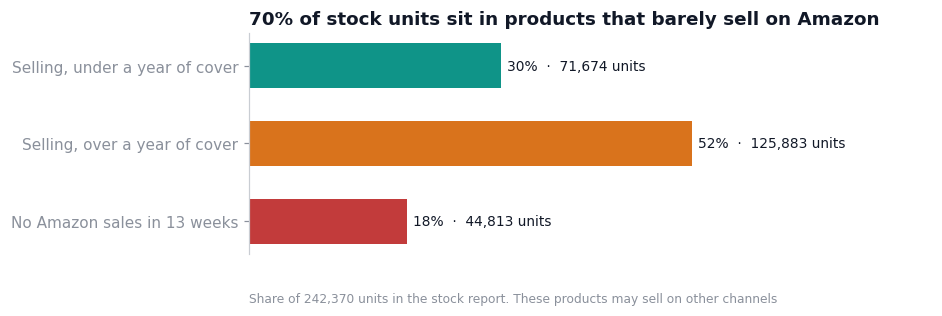

In [9]:
total_stock = stock.stock_units.sum()
sold_skus = set(d.sku)
not_selling = stock[~stock.sku.isin(sold_skus) & (stock.stock_units > 0)].stock_units.sum()
slow = d.loc[d.cover > 52, "stock_units"].sum()
healthy = total_stock - not_selling - slow
parts = pd.Series({"Selling, under a year of cover": healthy, "Selling, over a year of cover": slow, "No Amazon sales in 13 weeks": not_selling})

fig, ax = plt.subplots(figsize=(8, 2.6))
bars = ax.barh(parts.index, parts.values / total_stock, color=[TEAL, SAFFRON, RED], height=0.58)
ax.bar_label(bars, [f"{v/total_stock:.0%}  ·  {int(v):,} units" for v in parts.values], padding=4, color=INK, fontsize=9)
ax.invert_yaxis(); ax.set_xlim(0, 0.8); bare(ax)
ax.set_title(f"{(slow + not_selling)/total_stock:.0%} of stock units sit in products that barely sell on Amazon")
footnote(ax, f"Share of {int(total_stock):,} units in the stock report. These products may sell on other channels", y=-0.22)
fig.savefig(CHARTS / "08_stock_allocation.png")
plt.show()

## 7. A trap in the promotions column

Orders with a promotion code are almost never cancelled. That looks like a strong result, but it isn't one: the code is only written to the record when an order ships.

In [10]:
trap = (o.assign(cancelled=o.outcome.eq("Cancelled"), code=o.has_promotion.map({1: "Has a promotion code", 0: "No promotion code"}))
          .groupby("code").cancelled.agg(order_lines="size", cancelled="sum", cancel_rate="mean"))
display(trap.style.format({"order_lines": "{:,}", "cancelled": "{:,}", "cancel_rate": "{:.1%}"}))
print("Codes by fulfilment:", pd.crosstab(o.fulfilment, o.has_promotion).rename(columns={0: "no code", 1: "code"}).to_dict("index"))

,order_lines,cancelled,cancel_rate
code,,,
Has a promotion code,"79,819",295,0.4%
No promotion code,"49,150","18,034",36.7%


Codes by fulfilment: {'Fulfilled by Amazon': {'no code': 42221, 'code': 47471}, 'Shipped by seller': {'no code': 6929, 'code': 32348}}


**Why this is not a finding.** Only 295 of 18,329 cancelled orders carry a code, and the code types split perfectly by fulfilment method (free shipping only on Amazon-fulfilled orders, card financing only on seller-shipped ones). The field records what was applied at shipment, so it cannot explain cancellations. Reporting "promotions prevent cancellations" would be wrong.

## 8. Summary

| Question | Answer |
|---|---|
| Can the 2024 numbers be trusted? | No. It hid 41% of cancellations and counted cancelled orders as sales |
| How much revenue is real? | ₹69.7M net, not ₹78.6M |
| Ship it yourself or use Amazon? | Seller-shipped orders cancel at 17.5% vs 12.8%, in every category (p < 0.001) |
| Why is revenue falling? | Demand: fewer units a day, at slightly higher prices. Sets lost the most; Western Dresses are growing |
| Is stock in the right place? | No. A quarter of revenue sits on under two weeks of stock, while 70% of stock units barely sell on Amazon |
| Do promotions cut cancellations? | Can't be answered: the promotion field is only filled in for shipped orders |